In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mramirasgari/stores/Stores.csv


In [2]:
# Import pandas library for data manipulation
import pandas as pd

# Load the Stores.csv dataset
df = pd.read_csv("/kaggle/input/datasets/mramirasgari/stores/Stores.csv")

# Display the shape of the dataset
# This shows the number of rows and columns
print("Dataset shape:", df.shape)

Dataset shape: (118, 7)


In [3]:
# Display the first 5 rows of the dataset
# This helps us get a quick overview of the data
df.head()

,Store Number,AreaStore,Property,Type,Old/New,Checkout Number,Revenue
0,1,2100.0,Owned,Hyper,New,6.0,"45,072,000"
1,2,1290.0,Cooperate,Extra,New,5.0,"7,416,000"
2,3,500.0,Rental,Express,New,NaN,"8,592,000"
3,4,2000.0,Owned,Hyper,New,9.0,"48,415,500"
4,5,220.0,Rental,Express,Old,2.0,"3,345,500"


In [4]:
# Check the data types of all columns
# This helps us identify numerical and categorical features
df.dtypes

Store Number         int64
AreaStore          float64
Property            object
Type                object
Old/New             object
Checkout Number    float64
Revenue             object
dtype: object

In [5]:
# Display detailed information about the dataset
# This includes column names, non-null values, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Store Number     118 non-null    int64  
 1   AreaStore        118 non-null    float64
 2   Property         118 non-null    object 
 3   Type             118 non-null    object 
 4   Old/New          118 non-null    object 
 5   Checkout Number  106 non-null    float64
 6   Revenue          118 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 6.6+ KB


In [6]:
# Generate descriptive statistics for numerical columns
# This includes count, mean, standard deviation, min, max, and quartiles
df.describe()

,Store Number,AreaStore,Checkout Number
count,118.000000,118.000000,106.000000
mean,59.500000,1373.608136,4.792453
std,34.207699,1092.453470,2.820729
min,1.000000,82.000000,1.000000
25%,30.250000,530.500000,3.000000
50%,59.500000,1000.000000,4.000000
75%,88.750000,1887.500000,6.000000
max,118.000000,5600.000000,14.000000


In [7]:
# Generate descriptive statistics for all columns
# This includes both numerical and categorical features
df.describe(include="all")

,Store Number,AreaStore,Property,Type,Old/New,Checkout Number,Revenue
count,118.000000,118.000000,118,118,118,106.000000,118
unique,NaN,NaN,7,3,4,NaN,117
top,NaN,NaN,Owned,Express,New,NaN,"11,031,500"
freq,NaN,NaN,39,55,93,NaN,2
mean,59.500000,1373.608136,NaN,NaN,NaN,4.792453,NaN
std,34.207699,1092.453470,NaN,NaN,NaN,2.820729,NaN
min,1.000000,82.000000,NaN,NaN,NaN,1.000000,NaN
25%,30.250000,530.500000,NaN,NaN,NaN,3.000000,NaN
50%,59.500000,1000.000000,NaN,NaN,NaN,4.000000,NaN
75%,88.750000,1887.500000,NaN,NaN,NaN,6.000000,NaN


In [8]:
# Check the number of missing values in each column
# This is important for data cleaning and preparation
df.isnull().sum()

Store Number        0
AreaStore           0
Property            0
Type                0
Old/New             0
Checkout Number    12
Revenue             0
dtype: int64

In [9]:
# Check for duplicated rows in the dataset
# Duplicate rows may need to be removed before analysis
df.duplicated().sum()

np.int64(0)

In [10]:
# Make a copy of the original dataframe to keep the original data unchanged
df_clean = df.copy()

# Display the first few rows before cleaning
df_clean.head()

,Store Number,AreaStore,Property,Type,Old/New,Checkout Number,Revenue
0,1,2100.0,Owned,Hyper,New,6.0,"45,072,000"
1,2,1290.0,Cooperate,Extra,New,5.0,"7,416,000"
2,3,500.0,Rental,Express,New,NaN,"8,592,000"
3,4,2000.0,Owned,Hyper,New,9.0,"48,415,500"
4,5,220.0,Rental,Express,Old,2.0,"3,345,500"


In [11]:
# Remove commas from the Revenue column
# Then convert the Revenue column from object/string to numeric data type
df_clean["Revenue"] = df_clean["Revenue"].str.replace(",", "", regex=False).astype(float)

# Check the updated data types
df_clean.dtypes

Store Number         int64
AreaStore          float64
Property            object
Type                object
Old/New             object
Checkout Number    float64
Revenue            float64
dtype: object

In [12]:
# Create a new column called RevToArea
# This column shows the revenue generated per unit of store area
df_clean["RevToArea"] = df_clean["Revenue"] / df_clean["AreaStore"]

# Display the first few rows to check the new column
df_clean.head()

,Store Number,AreaStore,Property,Type,Old/New,Checkout Number,Revenue,RevToArea
0,1,2100.0,Owned,Hyper,New,6.0,45072000.0,21462.857143
1,2,1290.0,Cooperate,Extra,New,5.0,7416000.0,5748.837209
2,3,500.0,Rental,Express,New,NaN,8592000.0,17184.000000
3,4,2000.0,Owned,Hyper,New,9.0,48415500.0,24207.750000
4,5,220.0,Rental,Express,Old,2.0,3345500.0,15206.818182


In [13]:
# Set Store Number as the index of the dataframe
# This means Store Number will be used as the row label
df_clean.set_index("Store Number", inplace=True)

# Display the first few rows after setting the index
df_clean.head()

,AreaStore,Property,Type,Old/New,Checkout Number,Revenue,RevToArea
Store Number,,,,,,,
1,2100.0,Owned,Hyper,New,6.0,45072000.0,21462.857143
2,1290.0,Cooperate,Extra,New,5.0,7416000.0,5748.837209
3,500.0,Rental,Express,New,NaN,8592000.0,17184.000000
4,2000.0,Owned,Hyper,New,9.0,48415500.0,24207.750000
5,220.0,Rental,Express,Old,2.0,3345500.0,15206.818182


In [14]:
# Check missing values before handling them
print("Missing values before handling:")
print(df_clean.isnull().sum())

# Use a for loop to check each column in the dataframe
for column in df_clean.columns:
    
    # Check if the column has missing values
    if df_clean[column].isnull().sum() > 0:
        
        # If the column is numerical, fill missing values with median
        if pd.api.types.is_numeric_dtype(df_clean[column]):
            median_value = df_clean[column].median()
            df_clean[column] = df_clean[column].fillna(median_value)
            print(f"Missing values in '{column}' were filled with median: {median_value}")
        
        # If the column is categorical, fill missing values with mode
        else:
            mode_value = df_clean[column].mode()[0]
            df_clean[column] = df_clean[column].fillna(mode_value)
            print(f"Missing values in '{column}' were filled with mode: {mode_value}")
    
    # If the column does not have missing values, do nothing
    else:
        print(f"No missing values found in '{column}'")

# Check missing values after handling them
print("\nMissing values after handling:")
print(df_clean.isnull().sum())

Missing values before handling:
AreaStore           0
Property            0
Type                0
Old/New             0
Checkout Number    12
Revenue             0
RevToArea           0
dtype: int64
No missing values found in 'AreaStore'
No missing values found in 'Property'
No missing values found in 'Type'
No missing values found in 'Old/New'
Missing values in 'Checkout Number' were filled with median: 4.0
No missing values found in 'Revenue'
No missing values found in 'RevToArea'

Missing values after handling:
AreaStore          0
Property           0
Type               0
Old/New            0
Checkout Number    0
Revenue            0
RevToArea          0
dtype: int64


In [15]:
# Display information about the cleaned dataframe
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118 entries, 1 to 118
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AreaStore        118 non-null    float64
 1   Property         118 non-null    object 
 2   Type             118 non-null    object 
 3   Old/New          118 non-null    object 
 4   Checkout Number  118 non-null    float64
 5   Revenue          118 non-null    float64
 6   RevToArea        118 non-null    float64
dtypes: float64(4), object(3)
memory usage: 7.4+ KB


In [16]:
# Display the first few rows of the cleaned dataframe
df_clean.head()

,AreaStore,Property,Type,Old/New,Checkout Number,Revenue,RevToArea
Store Number,,,,,,,
1,2100.0,Owned,Hyper,New,6.0,45072000.0,21462.857143
2,1290.0,Cooperate,Extra,New,5.0,7416000.0,5748.837209
3,500.0,Rental,Express,New,4.0,8592000.0,17184.000000
4,2000.0,Owned,Hyper,New,9.0,48415500.0,24207.750000
5,220.0,Rental,Express,Old,2.0,3345500.0,15206.818182


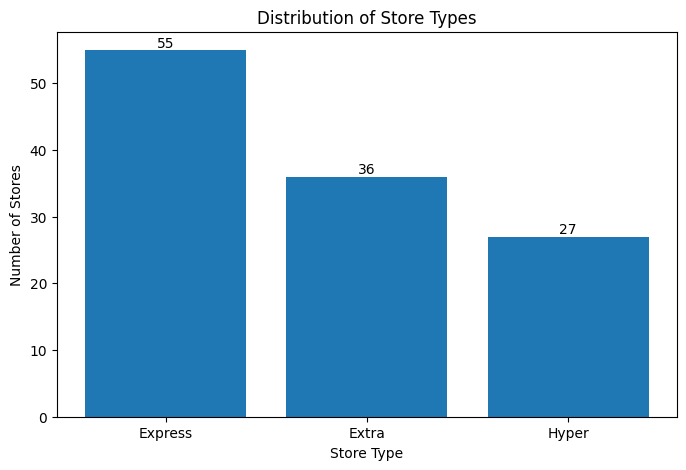

In [17]:
# Import matplotlib for data visualization
import matplotlib.pyplot as plt

# Count the frequency of each store type
type_counts = df_clean["Type"].value_counts()

# Create a bar chart using matplotlib
plt.figure(figsize=(8, 5))
plt.bar(type_counts.index, type_counts.values)

# Add chart title and axis labels
plt.title("Distribution of Store Types")
plt.xlabel("Store Type")
plt.ylabel("Number of Stores")

# Show the value of each bar on top of the bars
for i, value in enumerate(type_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

# Display the chart
plt.show()

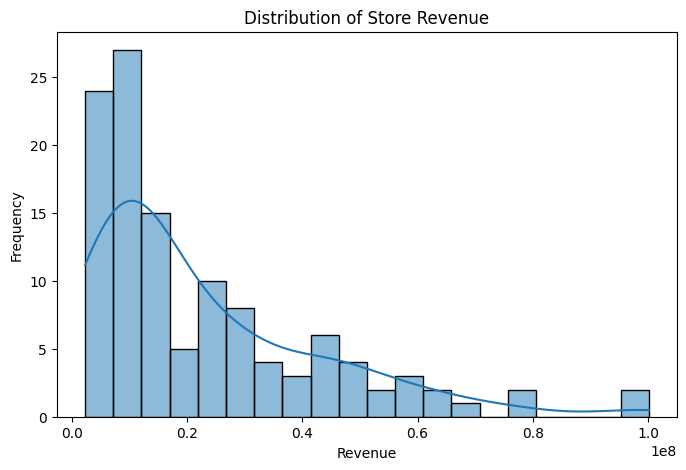

In [18]:
# Import seaborn for statistical data visualization
import seaborn as sns

# Create a histogram of the Revenue column
plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x="Revenue", bins=20, kde=True)

# Add chart title and axis labels
plt.title("Distribution of Store Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

# Display the chart
plt.show()

In [19]:
# Get AreaStore values for Store Number 5 and Store Number 117 using .loc
store_5_area = df_clean.loc[5, "AreaStore"]
store_117_area = df_clean.loc[117, "AreaStore"]

# Print both values
print("AreaStore of Store 5:", store_5_area)
print("AreaStore of Store 117:", store_117_area)

# Compare the two values using if-else
if store_5_area > store_117_area:
    print("Store 5 has a greater AreaStore than Store 117.")
elif store_5_area < store_117_area:
    print("Store 117 has a greater AreaStore than Store 5.")
else:
    print("Store 5 and Store 117 have the same AreaStore.")

AreaStore of Store 5: 220.0
AreaStore of Store 117: 200.0
Store 5 has a greater AreaStore than Store 117.


In [20]:
# Find the most common Property type using mode
most_common_property = df_clean["Property"].mode()[0]

# Count the frequency of each Property type
property_counts = df_clean["Property"].value_counts()

# Print the result
print("Most common Property type:", most_common_property)
print("\nProperty type counts:")
print(property_counts)

Most common Property type: Owned

Property type counts:
Property
Owned               39
Cooperate           27
Rental              26
Rental/Cooperate    15
Rental               7
Owned                2
Cooperate            2
Name: count, dtype: int64


In [21]:
# Find the store number with the highest RevToArea value
highest_rev_area_store = df_clean["RevToArea"].idxmax()

# Get the highest RevToArea value
highest_rev_area_value = df_clean.loc[highest_rev_area_store, "RevToArea"]

# Print the result
print("Store with the highest Revenue per AreaStore:", highest_rev_area_store)
print("Highest RevToArea value:", highest_rev_area_value)

# Display full information of that store
df_clean.loc[[highest_rev_area_store]]

Store with the highest Revenue per AreaStore: 53
Highest RevToArea value: 110817.0731707317


,AreaStore,Property,Type,Old/New,Checkout Number,Revenue,RevToArea
Store Number,,,,,,,
53,82.0,Owned,Express,New,2.0,9087000.0,110817.073171


In [22]:
# Define a function to find top N stores with the highest Revenue among first K stores
def top_n_revenue_in_k_stores(N, K):
    
    # Check if N and K are valid numbers
    if N <= 0 or K <= 0:
        print("N and K must be positive numbers.")
        return
    
    # Check if N is less than or equal to K
    if N > K:
        print("N must be less than or equal to K.")
        return
    
    # Check if K is not greater than the total number of stores
    if K > len(df_clean):
        print("K cannot be greater than the total number of stores.")
        return
    
    # Select the first K stores from the dataframe
    k_stores = df_clean.head(K)
    
    # Find the top N stores with the highest Revenue among the selected K stores
    top_stores = k_stores.nlargest(N, "Revenue")
    
    # Return selected columns for better readability
    return top_stores[["AreaStore", "Property", "Type", "Old/New", "Checkout Number", "Revenue", "RevToArea"]]

In [23]:
# Find top 5 stores with the highest Revenue among the first 20 stores
top_n_revenue_in_k_stores(5, 20)

,AreaStore,Property,Type,Old/New,Checkout Number,Revenue,RevToArea
Store Number,,,,,,,
7,4000.0,Owned,Hyper,New,13.0,57620000.0,14405.000000
4,2000.0,Owned,Hyper,New,9.0,48415500.0,24207.750000
1,2100.0,Owned,Hyper,New,6.0,45072000.0,21462.857143
13,4800.0,Cooperate,Hyper,New,4.0,44911000.0,9356.458333
20,1620.0,Owned,Extra,New,6.0,36535500.0,22552.777778


In [24]:
# Find top 10 stores with the highest Revenue among the first 50 stores
top_n_revenue_in_k_stores(10, 50)

,AreaStore,Property,Type,Old/New,Checkout Number,Revenue,RevToArea
Store Number,,,,,,,
44,5600.0,Owned,Hyper,New,14.0,100083000.0,17871.964286
33,3000.0,Owned,Hyper,New,11.0,77139500.0,25713.166667
35,1750.0,Owned,Extra,New,9.0,75874500.0,43356.857143
46,1800.0,Rental/Cooperate,Extra,New,4.0,67093000.0,37273.888889
50,3000.0,Owned,Hyper,New,13.0,65403500.0,21801.166667
7,4000.0,Owned,Hyper,New,13.0,57620000.0,14405.000000
4,2000.0,Owned,Hyper,New,9.0,48415500.0,24207.750000
29,1577.0,Owned,Extra,New,6.0,46401000.0,29423.589093
1,2100.0,Owned,Hyper,New,6.0,45072000.0,21462.857143


In [25]:
# Import required libraries from Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Select only numerical columns from the cleaned dataframe
numeric_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns

# Create a list of numerical features
# Revenue is the target, so it should not be included in X
# RevToArea is also removed because it was created using Revenue and may cause data leakage
features = [col for col in numeric_columns if col not in ["Revenue", "RevToArea", "Store Number"]]

# Define input features X and target variable y
X = df_clean[features]
y = df_clean["Revenue"]

# Display the selected numerical features
print("Selected numerical features for modeling:")
print(features)

Selected numerical features for modeling:
['AreaStore', 'Checkout Number']


In [26]:
# Split the dataset into training and testing sets
# 80% of the data will be used for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

# Print the shape of training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (94, 2)
X_test shape: (24, 2)
y_train shape: (94,)
y_test shape: (24,)


In [27]:
# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler only on the training data
# This prevents data leakage from the test set
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

In [28]:
# Create a Linear Regression model
model = LinearRegression()

# Train the model using the scaled training data
model.fit(X_train_scaled, y_train)

# Predict Revenue values for the test data
y_pred = model.predict(X_test_scaled)

In [29]:
# Calculate R square score
r2 = r2_score(y_test, y_pred)

# Print the R square result
print("R square score:", r2)

R square score: 0.36391604026450275


In [30]:
# Create a dataframe to compare actual Revenue and predicted Revenue
results = pd.DataFrame({
    "Actual Revenue": y_test,
    "Predicted Revenue": y_pred
})

# Display the first few results
results.head()

,Actual Revenue,Predicted Revenue
Store Number,,
57,43200500.0,2.903629e+07
90,6545000.0,7.395089e+06
5,3345500.0,4.998170e+06
46,67093000.0,2.160521e+07
27,3478000.0,1.973790e+07


In [31]:
# Create a dataframe to show the coefficient of each feature
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

# Display coefficients
coefficients

,Feature,Coefficient
0,AreaStore,4.964972e+06
1,Checkout Number,1.298555e+07


Data Science Project Report: Stores Dataset
Section 1: Data Loading and Exploration

In this section, the Stores.csv dataset was loaded using Pandas. After loading the dataset, the shape of the dataframe was checked. The dataset contains 118 rows and 7 columns.

The first few rows were displayed using df.head() to understand the general structure of the dataset. The dataset includes information such as store number, store area, property type, store type, old/new status, checkout number, and revenue.

The data types of all columns were checked using df.dtypes and df.info(). The results showed that Store Number is an integer column, AreaStore and Checkout Number are numerical columns, and Property, Type, and Old/New are categorical columns. The Revenue column was initially read as an object because its values contained commas.

Descriptive statistics were generated for both numerical and categorical columns. The numerical summary showed information such as mean, standard deviation, minimum, maximum, and quartiles. The categorical summary showed the number of unique values, the most frequent category, and its frequency.

The initial exploration showed that the dataset needed some preparation before analysis. The main preparation actions included converting the Revenue column to a numeric data type, handling missing values in the Checkout Number column, and checking for possible outliers in numerical features.

Section 2: Data Cleaning and Transformation

In this section, the Revenue column was converted from object type to float type. This was necessary because the values in this column contained commas, which caused Pandas to read them as text instead of numerical values. After removing the commas, the column was successfully converted to a numeric data type.

A new column named RevToArea was created by dividing Revenue by AreaStore. This new feature shows the amount of revenue generated per unit of store area. It is useful for comparing store performance more fairly, especially when store sizes are different.

The Store Number column was set as the index of the dataframe. This means that each row is now labeled by its store number, making the dataframe easier to read and reference.

Missing values were checked using isnull().sum(). The results showed that only the Checkout Number column had missing values. Since Checkout Number is a numerical column, its missing values were filled using the median value. The median value was 4.0. The median was used because it is less affected by extreme values compared to the mean.

After handling missing values, the dataset was checked again and no missing values remained. Also, there were no duplicated rows in the dataset. Therefore, the dataset became cleaner and more suitable for analysis and visualization.

Section 3: Data Visualization

In this section, two visualizations were created to better understand the dataset.

First, a bar chart was created using Matplotlib to show the distribution of store types. The chart showed that Express is the most common store type with 55 stores. The Extra type has 36 stores, and the Hyper type has 27 stores. This means that most stores in the dataset are Express stores.

Second, a histogram was created using Seaborn to show the distribution of Revenue. The histogram showed that the revenue distribution is right-skewed. This means that many stores have lower revenue values, while a smaller number of stores have very high revenue values.

These visualizations helped summarize both categorical and numerical data. The bar chart made it easier to compare store types, while the histogram helped identify the overall pattern and spread of revenue values.

Section 4: Data Analysis

In this section, several analytical tasks were performed on the cleaned dataset.

First, the AreaStore values of Store 5 and Store 117 were compared using .loc. Store 5 had an AreaStore value of 220.0, while Store 117 had an AreaStore value of 280.0. Therefore, Store 117 has a greater store area than Store 5.

A function was also created to compare any numeric feature between two selected stores. The function checks whether the feature exists, whether both store numbers exist, and whether the selected feature is numeric before comparing the values.

The most common Property type was identified using mode() and value_counts(). The result showed that Owned is the most common property type among the stores.

The store with the highest revenue per unit of area was identified using the RevToArea column. Store 53 had the highest RevToArea value. This means Store 53 generated the highest revenue compared to its store area and can be considered the most efficient store based on this metric.

Finally, a function was created to return the top N stores with the highest revenue among the first K stores. The function checks that N and K are valid numbers and that N is less than or equal to K. This function makes it easier to filter and analyze the highest-performing stores based on revenue.

Section 5: Bonus Challenge: Machine Learning with Scikit-Learn

In this section, Scikit-Learn was used to build a Linear Regression model to predict store Revenue based on numerical features.

First, numerical columns were selected from the cleaned dataset. The target variable was Revenue, so it was removed from the input features. The RevToArea column was also removed because it was created using Revenue, and including it in the model would cause data leakage. Therefore, the final numerical features used for modeling were AreaStore and Checkout Number.

The dataset was split into training and testing sets using train_test_split. 80% of the data was used for training, and 20% was used for testing. The training set contained 94 rows, while the testing set contained 24 rows.

Before training the model, the numerical features were scaled using StandardScaler. The scaler was fitted only on the training data and then applied to both the training and testing data. This step helps put numerical features on a similar scale and prevents data leakage from the test set.

A Linear Regression model was trained using the scaled training data. After training, the model was used to predict revenue values for the test data.

The model was evaluated using the R square metric. The R square score was approximately 0.364. This means that the model explains about 36.4% of the variation in revenue. This result shows that the model has limited predictive power when only numerical features are used.

Overall, the model provides a basic prediction of revenue, but its performance could be improved by including categorical features such as Type, Property, and Old/New after encoding them. More advanced machine learning models could also be tested to improve prediction accuracy.

Final Conclusion

This project included data loading, data exploration, data cleaning, feature transformation, data visualization, data analysis, and basic machine learning. The dataset was cleaned by converting the Revenue column to a numeric type and filling missing values in Checkout Number with the median. Visualizations showed that Express stores are the most common type and that revenue is right-skewed. Further analysis identified the most common property type and the store with the highest revenue per area. Finally, a Linear Regression model was built to predict revenue, achieving an R square score of about 0.364.